# 📘 Module 3.2 — LSTM, GRU & Sequence Modeling

**Goal:** Master LSTM and GRU — the workhorses for temporal data in ADAS.

## LSTM vs GRU
| Feature | LSTM | GRU |
|---------|------|-----|
| Gates | 3 (forget, input, output) | 2 (reset, update) |
| Parameters | More | Fewer |
| Performance | Slightly better on long sequences | Faster training |
| Usage in ADAS | Trajectory prediction | Real-time applications |

---

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

## 1. LSTM (Long Short-Term Memory)

LSTM adds a **cell state** (long-term memory) controlled by gates:

```
Forget Gate:  f_t = σ(W_f · [h_{t-1}, x_t] + b_f)    → What to forget
Input Gate:   i_t = σ(W_i · [h_{t-1}, x_t] + b_i)    → What to remember
Cell Update:  c̃_t = tanh(W_c · [h_{t-1}, x_t] + b_c) → New candidate
Cell State:   c_t = f_t ⊙ c_{t-1} + i_t ⊙ c̃_t        → Update memory
Output Gate:  o_t = σ(W_o · [h_{t-1}, x_t] + b_o)    → What to output
Hidden State: h_t = o_t ⊙ tanh(c_t)                   → Output
```

**Key Insight:** The cell state flows through time with minimal modification (like a highway), solving vanishing gradients!

In [2]:
# --- PyTorch LSTM ---
lstm = nn.LSTM(
    input_size=6,       # 6 sensor features (e.g., accel_x/y/z, gyro_x/y/z)
    hidden_size=32,     # Hidden state size
    num_layers=2,       # 2 stacked LSTM layers
    batch_first=True,
    dropout=0.1,        # Dropout between layers
)

# Simulated IMU sensor data: 8 sequences, 100 timesteps, 6 features
x = torch.randn(8, 100, 6)

# LSTM returns output AND (hidden_state, cell_state)
output, (h_n, c_n) = lstm(x)

print(f"Input:        {x.shape}       (batch, seq_len, features)")
print(f"Output:       {output.shape}  (batch, seq_len, hidden)")
print(f"Hidden state: {h_n.shape}      (layers, batch, hidden)")
print(f"Cell state:   {c_n.shape}      (layers, batch, hidden)")
print(f"\nLSTM has BOTH hidden state (short-term) and cell state (long-term memory)")

Input:        torch.Size([8, 100, 6])       (batch, seq_len, features)
Output:       torch.Size([8, 100, 32])  (batch, seq_len, hidden)
Hidden state: torch.Size([2, 8, 32])      (layers, batch, hidden)
Cell state:   torch.Size([2, 8, 32])      (layers, batch, hidden)

LSTM has BOTH hidden state (short-term) and cell state (long-term memory)


## 2. GRU (Gated Recurrent Unit)

GRU simplifies LSTM by combining forget and input gates into a single **update gate**.

In [3]:
# --- PyTorch GRU ---
gru = nn.GRU(
    input_size=6,
    hidden_size=32,
    num_layers=2,
    batch_first=True,
    dropout=0.1,
)

x = torch.randn(8, 100, 6)
output, h_n = gru(x)  # GRU only returns hidden state (no cell state)

print(f"GRU Output: {output.shape}")
print(f"GRU Hidden: {h_n.shape}")

# Parameter comparison
lstm_params = sum(p.numel() for p in lstm.parameters())
gru_params = sum(p.numel() for p in gru.parameters())
print(f"\nLSTM parameters: {lstm_params:,}")
print(f"GRU parameters:  {gru_params:,}")
print(f"GRU is {(1 - gru_params/lstm_params)*100:.0f}% smaller!")

GRU Output: torch.Size([8, 100, 32])
GRU Hidden: torch.Size([2, 8, 32])

LSTM parameters: 13,568
GRU parameters:  10,176
GRU is 25% smaller!


## 3. Practical Example: Vehicle Speed Prediction

Given past speed readings, predict future speed — a core ADAS task for adaptive cruise control.

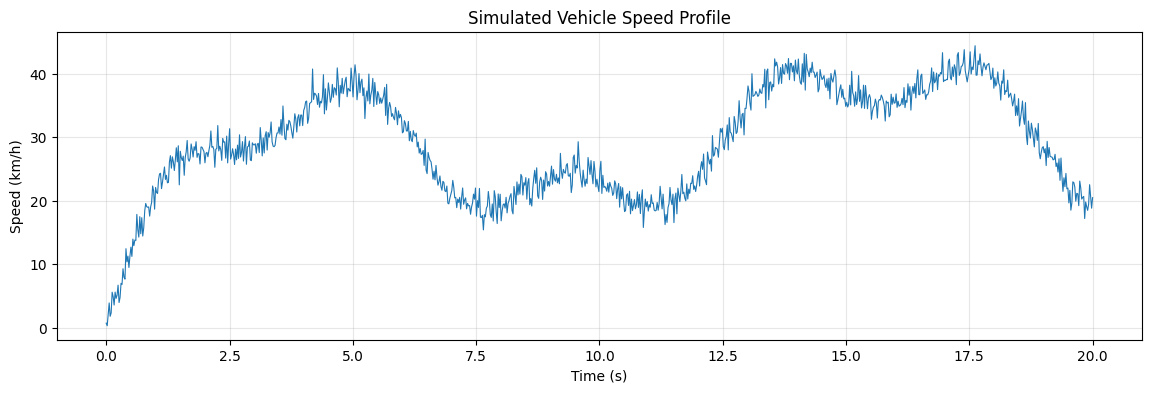

In [4]:
# --- Generate Synthetic Speed Data ---
np.random.seed(42)
t = np.linspace(0, 20, 1000)

# Simulate realistic driving: accelerate, cruise, brake, cruise
speed = (
    30 * (1 - np.exp(-t/2)) +        # Initial acceleration
    10 * np.sin(0.5 * t) +             # Speed variations
    5 * np.sin(1.5 * t) +              # Road undulations
    np.random.randn(len(t)) * 1.5      # Noise
)
speed = np.clip(speed, 0, 80)  # Realistic speed range

plt.figure(figsize=(14, 4))
plt.plot(t, speed, linewidth=0.8)
plt.xlabel('Time (s)')
plt.ylabel('Speed (km/h)')
plt.title('Simulated Vehicle Speed Profile')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# --- Prepare Sequences ---
def create_sequences(data, seq_length, pred_length=1):
    """Create input/target pairs for sequence prediction."""
    X, y = [], []
    for i in range(len(data) - seq_length - pred_length + 1):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length:i+seq_length+pred_length])
    return np.array(X), np.array(y)

# Normalize speed data
speed_mean, speed_std = speed.mean(), speed.std()
speed_norm = (speed - speed_mean) / speed_std

SEQ_LENGTH = 50  # Use 50 past readings
X, y = create_sequences(speed_norm, SEQ_LENGTH)

# Split train/test
split = int(0.8 * len(X))
X_train = torch.FloatTensor(X[:split]).unsqueeze(-1)  # Add feature dim
y_train = torch.FloatTensor(y[:split])
X_test = torch.FloatTensor(X[split:]).unsqueeze(-1)
y_test = torch.FloatTensor(y[split:])

print(f"Training: X={X_train.shape}, y={y_train.shape}")
print(f"Testing:  X={X_test.shape}, y={y_test.shape}")

Training: X=torch.Size([760, 50, 1]), y=torch.Size([760, 1])
Testing:  X=torch.Size([190, 50, 1]), y=torch.Size([190, 1])


In [6]:
# --- LSTM Speed Predictor ---
class SpeedPredictor(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers,
                           batch_first=True, dropout=0.1)
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # x: (batch, seq_len, 1)
        lstm_out, _ = self.lstm(x)           # (batch, seq_len, hidden)
        last_output = lstm_out[:, -1, :]     # Take last time step
        prediction = self.fc(last_output)     # (batch, 1)
        return prediction

model = SpeedPredictor()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print(model)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

SpeedPredictor(
  (lstm): LSTM(1, 64, num_layers=2, batch_first=True, dropout=0.1)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Parameters: 50,497


Epoch 10/30, Loss: 0.040364


Epoch 20/30, Loss: 0.038598


Epoch 30/30, Loss: 0.037912


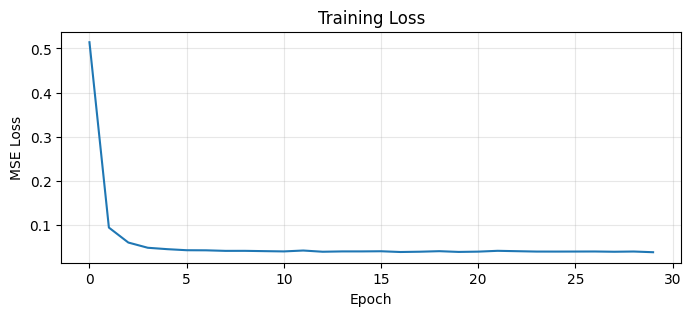

In [7]:
# --- Training Loop ---
from torch.utils.data import DataLoader, TensorDataset

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

losses = []
model.train()

for epoch in range(30):
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        pred = model(batch_x)
        loss = criterion(pred, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/30, Loss: {avg_loss:.6f}")

plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid(True, alpha=0.3)
plt.show()

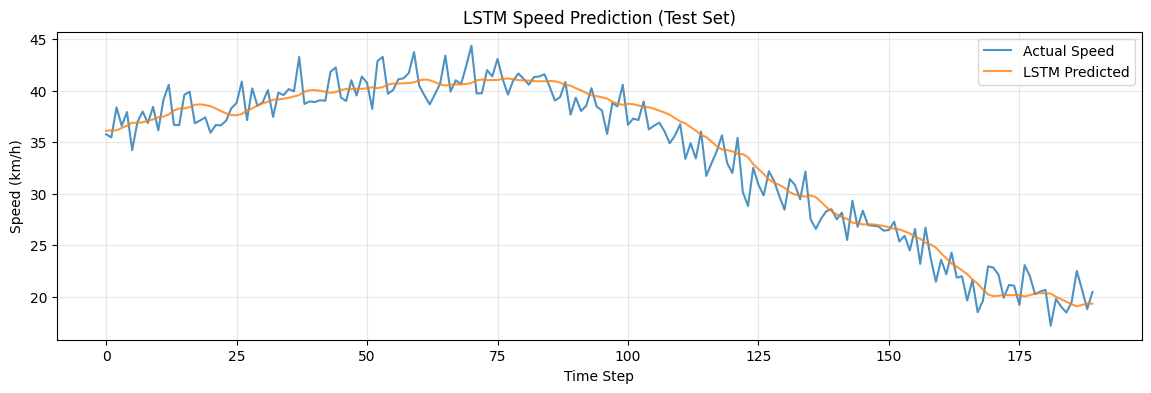

RMSE: 1.63 km/h


In [8]:
# --- Evaluate and Visualize ---
model.eval()
with torch.no_grad():
    predictions = model(X_test).numpy().flatten()

# Denormalize
pred_speed = predictions * speed_std + speed_mean
true_speed = y_test.numpy().flatten() * speed_std + speed_mean

plt.figure(figsize=(14, 4))
plt.plot(true_speed[:200], label='Actual Speed', alpha=0.8)
plt.plot(pred_speed[:200], label='LSTM Predicted', alpha=0.8)
plt.xlabel('Time Step')
plt.ylabel('Speed (km/h)')
plt.title('LSTM Speed Prediction (Test Set)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

rmse = np.sqrt(np.mean((pred_speed - true_speed)**2))
print(f"RMSE: {rmse:.2f} km/h")

## 4. Bidirectional RNN

**Bidirectional** RNNs process the sequence in both directions — useful when you have the full sequence available (not real-time).

In [9]:
bi_lstm = nn.LSTM(
    input_size=6,
    hidden_size=32,
    num_layers=2,
    batch_first=True,
    bidirectional=True,  # Process forward AND backward
)

x = torch.randn(8, 100, 6)
output, (h_n, c_n) = bi_lstm(x)

print(f"Bidirectional LSTM:")
print(f"  Output: {output.shape}  (hidden_size × 2 because of both directions)")
print(f"  Hidden: {h_n.shape}  (num_layers × 2 directions)")

Bidirectional LSTM:
  Output: torch.Size([8, 100, 64])  (hidden_size × 2 because of both directions)
  Hidden: torch.Size([4, 8, 32])  (num_layers × 2 directions)


---
## ✅ Key Takeaways

1. **LSTM** solves vanishing gradients with gates and a cell state (long-term memory)
2. **GRU** is simpler and faster than LSTM with comparable performance
3. For **real-time ADAS** (speed prediction, trajectory), use unidirectional LSTM/GRU
4. For **offline analysis** (recorded driving data), bidirectional models can be better
5. **Sequence-to-one** (predict next step) vs **Sequence-to-sequence** (predict next N steps)

---
## 📖 Next Steps
➡️ **Next module:** [04_Transformers/01_attention_mechanism.ipynb](../04_Transformers/01_attention_mechanism.ipynb) — The attention mechanism that revolutionized everything